<a href="https://colab.research.google.com/github/yasmeen-mukhtiar7/6DOF-Robotic-Arm-Pick-and-Place-Simulation/blob/main/heartdisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Heart Disease Risk Prediction Project
## Machine Learning Lab - Semester 6
**Student:** Yasmeen Mukhtiar (L1F23BSRI0018)

**Models Used:** Logistic Regression (Baseline) vs. K-Nearest Neighbors (KNN).

In [147]:
# Cell 2: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# For saving the model later
import joblib

# Makes plots look nicer
sns.set_style("whitegrid")

Libraries imported successfully!


In [148]:
# Cell 3: Loading the data from Kaggle
from google.colab import files

# Load the dataset
import io
df = pd.read_csv(io.BytesIO(uploaded['heart.csv']))

print(f"\n Dataset loaded successfully!")
print(f"Shape of dataset: {df.shape} (Rows, Columns)")
df.head()


 Dataset loaded successfully!
Shape of dataset: (918, 12) (Rows, Columns)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


3- Dataset Overview

In [149]:
# Cell 4: Basic info and missing values check
print("=== Dataset Information ===")
df.info()

print("\n=== Checking for Missing Values ===")
print(df.isnull().sum())

print("\n=== Statistical Summary ===")
df.describe()

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

=== Checking for Missing Values ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG       

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Counts:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Percentage with Heart Disease: 55.34%


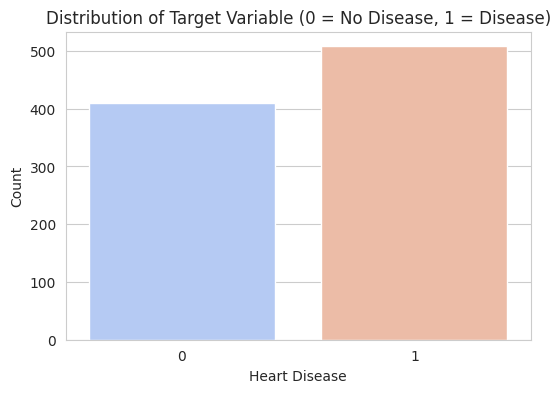

In [150]:
# Cell 5: Check distribution of Heart Disease
plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=df, palette='coolwarm', hue='HeartDisease', legend=False)
plt.title('Distribution of Target Variable (0 = No Disease, 1 = Disease)')
plt.xlabel('Heart Disease')
plt.ylabel('Count')

# Calculate percentages
counts = df['HeartDisease'].value_counts()
print(f"Counts:\n{counts}")
print(f"\nPercentage with Heart Disease: {counts[1]/len(df)*100:.2f}%")
plt.show()

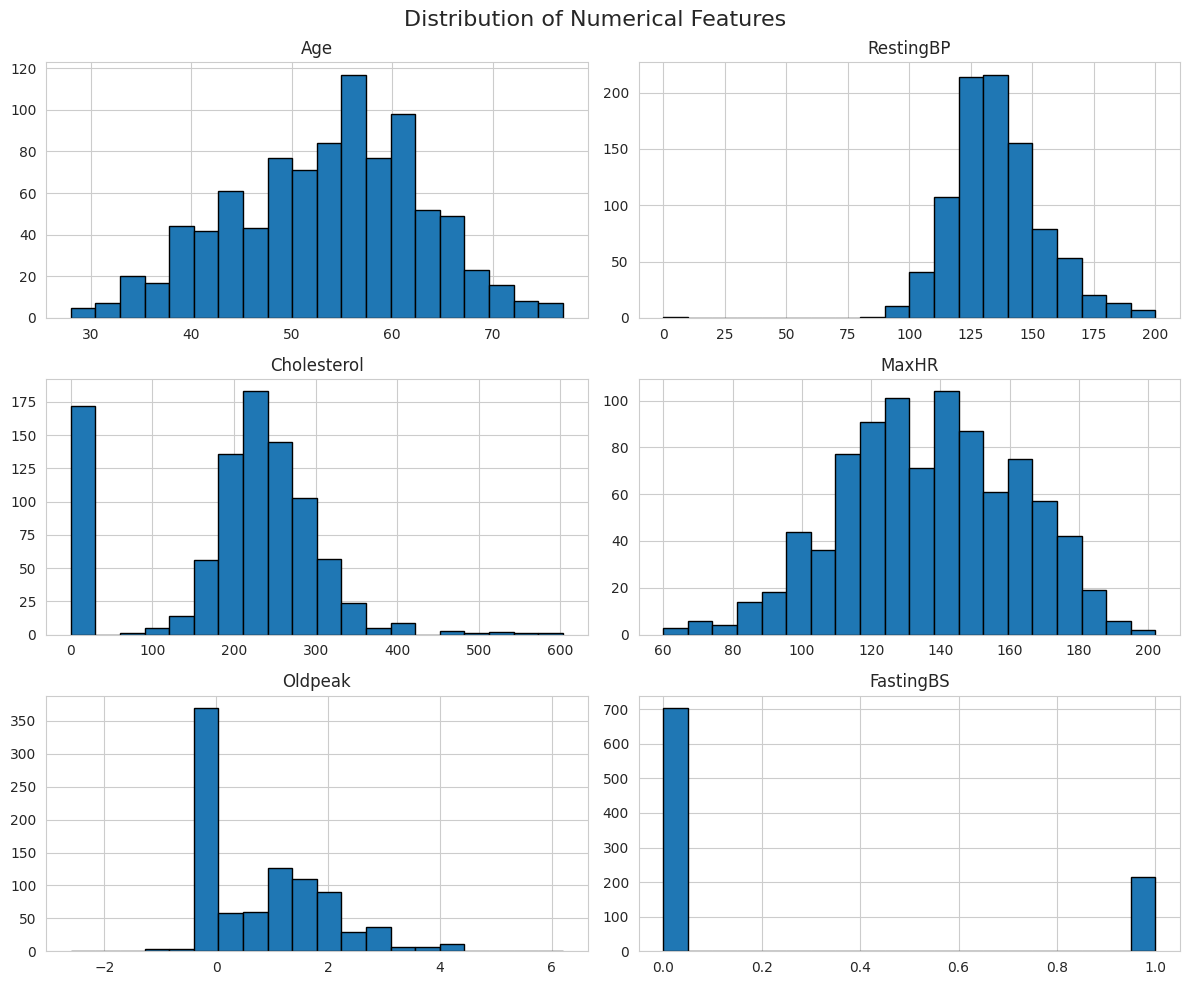

In [151]:
# Cell 6: Visualize numerical features
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS']

df[numerical_cols].hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', size=16)
plt.tight_layout()
plt.show()

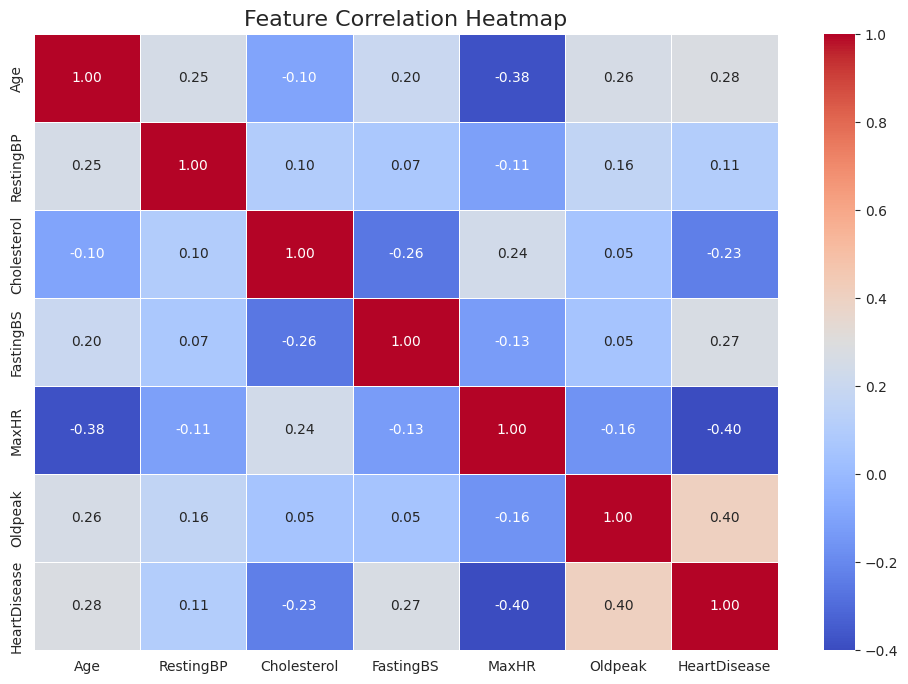

In [152]:
# Cell 7: Correlation Heatmap (Only numerical columns)
plt.figure(figsize=(12, 8))

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', size=16)
plt.show()

In [153]:
# Cell 8: Define X and y
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (918, 11)
Target shape: (918,)


In [154]:
# Cell 9: Convert categorical text to numbers using One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

print(" Categorical variables encoded!")
print(f"New feature shape: {X_encoded.shape}")
X_encoded.head()

 Categorical variables encoded!
New feature shape: (918, 15)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,True,False,True,False,True,False,False,False,True


In [155]:
# Cell 10: Split 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Scale the features (CRUCIAL for KNN, good for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Testing samples: {X_test_scaled.shape[0]}")

Training samples: 734
Testing samples: 184


In [156]:
# Display the first 5 rows of the scaled training features
print("First 5 rows of X_train_scaled:")
print(X_train_scaled[:5])

First 5 rows of X_train_scaled:
[[-1.24506731 -0.70898547  0.372803    1.84260945  2.28435288 -0.09706109
   0.54060477 -0.48333575  1.87905939 -0.21350421  0.80817891 -0.48762079
  -0.83846064 -1.03325003 -0.84792072]
 [-1.8862362  -0.16628515  0.08614581 -0.5427086   1.65224147 -0.83628643
   0.54060477 -0.48333575  1.87905939 -0.21350421  0.80817891 -0.48762079
  -0.83846064 -1.03325003  1.17935554]
 [ 0.25099346  0.91911549  0.12313384  1.84260945 -0.44162756  0.08774524
   0.54060477 -0.48333575 -0.53218116 -0.21350421  0.80817891 -0.48762079
   1.19266183  0.96781995 -0.84792072]
 [-1.77937472 -0.16628515  0.10463982 -0.5427086   0.22999081 -0.83628643
  -1.84978019 -0.48333575  1.87905939 -0.21350421  0.80817891 -0.48762079
  -0.83846064 -1.03325003  1.17935554]
 [-0.28331396 -0.70898547 -1.84647842  1.84260945 -1.27127378 -0.83628643
   0.54060477 -0.48333575 -0.53218116 -0.21350421  0.80817891 -0.48762079
  -0.83846064  0.96781995 -0.84792072]]


In [157]:
# Cell 11: MASTER DIAGNOSIS - Check All Features & Fix Overfitting/Underfitting
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV

print("="*70)
print(" STEP 1: DIAGNOSING THE RAW MODEL (All 11 Features)")
print("="*70)

# --- 1. TEST RAW LOGISTIC REGRESSION (All Features) ---
lr_raw = LogisticRegression(random_state=42)
lr_raw.fit(X_train_scaled, y_train)
lr_raw_train = lr_raw.score(X_train_scaled, y_train)
lr_raw_test = lr_raw.score(X_test_scaled, y_test)
lr_raw_gap = lr_raw_train - lr_raw_test

print("\n  LOGISTIC REGRESSION (Raw - All 11 Features):")
print(f"   Training Acc: {lr_raw_train:.4f}")
print(f"   Testing Acc:  {lr_raw_test:.4f}")
print(f"   Gap:          {lr_raw_gap:.4f}")

# --- 2. TEST RAW KNN (All Features, K=5) ---
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train_scaled, y_train)
knn_raw_train = knn_raw.score(X_train_scaled, y_train)
knn_raw_test = knn_raw.score(X_test_scaled, y_test)
knn_raw_gap = knn_raw_train - knn_raw_test

print("\n  KNN (Raw - All 11 Features, K=5):")
print(f"   Training Acc: {knn_raw_train:.4f}")
print(f"   Testing Acc:  {knn_raw_test:.4f}")
print(f"   Gap:          {knn_raw_gap:.4f}")

# --- 3. INTERPRETATION & FIXES ---
print("\n" + "="*70)
print(" STEP 2: APPLYING PREPROCESSING TO FIX ISSUES")
print("="*70)

# --- FIX 1: LOGISTIC REGRESSION (If overfitting, add stronger regularization) ---
lr_best = LogisticRegression(random_state=42)
if lr_raw_gap > 0.10:
    print("\n Logistic Regression shows OVERFITTING (Gap > 10%). Applying stronger Regularization...")
    # Test different C values (smaller C = stronger regularization)
    C_values = [0.001, 0.01, 0.1, 1, 10, 100]
    best_c = 1
    best_test_score = 0
    for c in C_values:
        lr_temp = LogisticRegression(C=c, random_state=42)
        lr_temp.fit(X_train_scaled, y_train)
        test_score = lr_temp.score(X_test_scaled, y_test)
        if test_score > best_test_score:
            best_test_score = test_score
            best_c = c
    lr_best = LogisticRegression(C=best_c, random_state=42)
    lr_best.fit(X_train_scaled, y_train)
    lr_fixed_train = lr_best.score(X_train_scaled, y_train)
    lr_fixed_test = lr_best.score(X_test_scaled, y_test)
    print(f"   Fixed! Using C={best_c} (Stronger regularization).")
    print(f"   New Training Acc: {lr_fixed_train:.4f}")
    print(f"   New Testing Acc:  {lr_fixed_test:.4f}")
    print(f"   New Gap:          {lr_fixed_train - lr_fixed_test:.4f}")
else:
    print("\n Logistic Regression is already STABLE (Gap < 10%). Keeping Raw model.")
    lr_best = lr_raw
    lr_fixed_train, lr_fixed_test = lr_raw_train, lr_raw_test

# --- FIX 2: KNN (If overfitting, remove noisy features using RFE and tune K) ---
if knn_raw_gap > 0.10:
    print("\n KNN shows OVERFITTING (Gap > 10%). Applying Feature Selection (RFE) + Tuning K...")

    # Step A: Use RFE to find the best number of features (try 5 to 9)
    best_knn_test = 0
    best_k = 5
    best_n_features = 6
    best_knn_model = None

    # Test feature counts from 4 to 9
    for n_features in range(4, 10):
        selector = RFE(estimator=LogisticRegression(random_state=42), n_features_to_select=n_features)
        X_train_rfe = selector.fit_transform(X_train_scaled, y_train)
        X_test_rfe = selector.transform(X_test_scaled)

        # Test K values from 3 to 15
        for k in range(3, 16, 2):
            knn_temp = KNeighborsClassifier(n_neighbors=k)
            knn_temp.fit(X_train_rfe, y_train)
            test_score = knn_temp.score(X_test_rfe, y_test)
            if test_score > best_knn_test:
                best_knn_test = test_score
                best_k = k
                best_n_features = n_features
                best_knn_model = knn_temp
                # Store the selected feature mask for later use
                best_mask = selector.support_
                best_columns = X_encoded.columns[best_mask].tolist()

    # We need to refit the final model properly to get train/test scores
    final_selector = RFE(estimator=LogisticRegression(random_state=42), n_features_to_select=best_n_features)
    X_train_final = final_selector.fit_transform(X_train_scaled, y_train)
    X_test_final = final_selector.transform(X_test_scaled)

    knn_fixed = KNeighborsClassifier(n_neighbors=best_k)
    knn_fixed.fit(X_train_final, y_train)
    knn_fixed_train = knn_fixed.score(X_train_final, y_train)
    knn_fixed_test = knn_fixed.score(X_test_final, y_test)
    selected_cols = X_encoded.columns[final_selector.support_].tolist()

    print(f"   Fixed! Selected Top {best_n_features} Features: {', '.join(selected_cols)}")
    print(f"   Optimal K found: {best_k}")
    print(f"   New Training Acc: {knn_fixed_train:.4f}")
    print(f"   New Testing Acc:  {knn_fixed_test:.4f}")
    print(f"   New Gap:          {knn_fixed_train - knn_fixed_test:.4f}")

    # Save these for the final comparison
    knn_best = knn_fixed
    knn_final_train, knn_final_test = knn_fixed_train, knn_fixed_test
    X_train_final_knn, X_test_final_knn = X_train_final, X_test_final

else:
    print("\n KNN is already STABLE (Gap < 10%). Keeping Raw model (All 11 features, K=5).")
    knn_best = knn_raw
    knn_final_train, knn_final_test = knn_raw_train, knn_raw_test
    X_train_final_knn, X_test_final_knn = X_train_scaled, X_test_scaled
    selected_cols = X_encoded.columns.tolist()

# --- 4. FINAL VERDICT ---
print("\n" + "="*70)
print(" STEP 3: FINAL COMPARISON (Raw vs Optimized)")
print("="*70)

print("\n LOGISTIC REGRESSION:")
print(f"   Raw Test Accuracy:      {lr_raw_test:.4f}")
print(f"   Optimized Test Accuracy: {lr_fixed_test:.4f}")
print(f"   Status: {' IMPROVED' if lr_fixed_test > lr_raw_test else ' STABLE'}")

print("\n KNN:")
print(f"   Raw Test Accuracy:      {knn_raw_test:.4f}")
print(f"   Optimized Test Accuracy: {knn_final_test:.4f}")
if knn_raw_gap > 0.10:
    print(f"   Status:  FIXED OVERFITTING! (Gap reduced from {knn_raw_gap:.4f} to {knn_final_train - knn_final_test:.4f})")
    print(f"   Features used now: {len(selected_cols)} out of 11 (Noise removed)")
else:
    print(f"   Status:  STABLE (No preprocessing needed)")

print("\n" + "="*70)
print(" RECOMMENDATION FOR YOUR FINAL MODEL:")
if lr_fixed_test >= knn_final_test:
    print("   Use LOGISTIC REGRESSION as your final model.")
    best_final_model = "Logistic Regression"
else:
    print("   Use KNN (with optimized features) as your final model.")
    best_final_model = "KNN"
print("="*70)

 STEP 1: DIAGNOSING THE RAW MODEL (All 11 Features)

  LOGISTIC REGRESSION (Raw - All 11 Features):
   Training Acc: 0.8719
   Testing Acc:  0.8533
   Gap:          0.0187

  KNN (Raw - All 11 Features, K=5):
   Training Acc: 0.8951
   Testing Acc:  0.8533
   Gap:          0.0418

 STEP 2: APPLYING PREPROCESSING TO FIX ISSUES

 Logistic Regression is already STABLE (Gap < 10%). Keeping Raw model.

 KNN is already STABLE (Gap < 10%). Keeping Raw model (All 11 features, K=5).

 STEP 3: FINAL COMPARISON (Raw vs Optimized)

 LOGISTIC REGRESSION:
   Raw Test Accuracy:      0.8533
   Optimized Test Accuracy: 0.8533
   Status:  STABLE

 KNN:
   Raw Test Accuracy:      0.8533
   Optimized Test Accuracy: 0.8533
   Status:  STABLE (No preprocessing needed)

 RECOMMENDATION FOR YOUR FINAL MODEL:
   Use LOGISTIC REGRESSION as your final model.


In [158]:
# Cell 11: Train Logistic Regression with Cross-Validation
lr = LogisticRegression(random_state=42)

# 5-Fold Cross-Validation on Training set
cv_scores_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5)
print(f"Logistic Regression - 5-Fold CV Scores: {cv_scores_lr}")
print(f"Logistic Regression - Mean CV Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

# Train on full training set
lr.fit(X_train_scaled, y_train)

# Predictions on Test set
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]  # Probability for risk percentage

print("\n Logistic Regression training complete!")

Logistic Regression - 5-Fold CV Scores: [0.88435374 0.87755102 0.86394558 0.82993197 0.8630137 ]
Logistic Regression - Mean CV Accuracy: 0.8638 (+/- 0.0188)

 Logistic Regression training complete!


 	 	 LOGISTIC REGRESSION - PERFORMANCE REPORT
 Test Accuracy: 0.8533
 ROC-AUC Score: 0.9267

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184


Confusion Matrix:


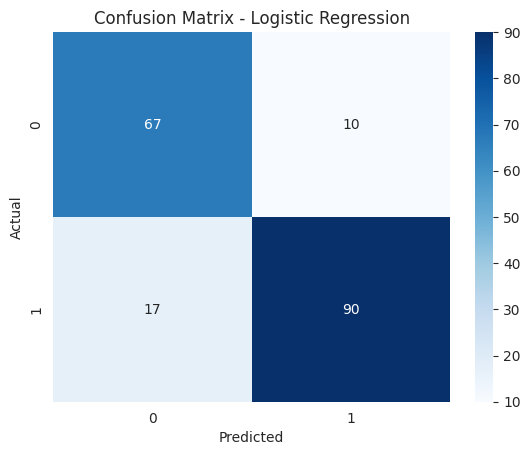

In [169]:
# Cell 12: Metrics for Logistic Regression
print(" \t \t LOGISTIC REGRESSION - PERFORMANCE REPORT")

accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f" Test Accuracy: {accuracy_lr:.4f}")
print(f" ROC-AUC Score: {roc_auc_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [160]:
# Cell 13: Train KNN with Cross-Validation
knn = KNeighborsClassifier(n_neighbors=5)

cv_scores_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5)
print(f"KNN - 5-Fold CV Scores: {cv_scores_knn}")
print(f"KNN - Mean CV Accuracy: {cv_scores_knn.mean():.4f} (+/- {cv_scores_knn.std():.4f})")

# Train on full training set
knn.fit(X_train_scaled, y_train)

# Predictions on Test set
y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

print("\n KNN training complete!")

KNN - 5-Fold CV Scores: [0.87755102 0.8707483  0.86394558 0.82312925 0.84246575]
KNN - Mean CV Accuracy: 0.8556 (+/- 0.0200)

 KNN training complete!


 KNN - PERFORMANCE REPORT
 Test Accuracy: 0.8533
 ROC-AUC Score: 0.9237

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184


Confusion Matrix:


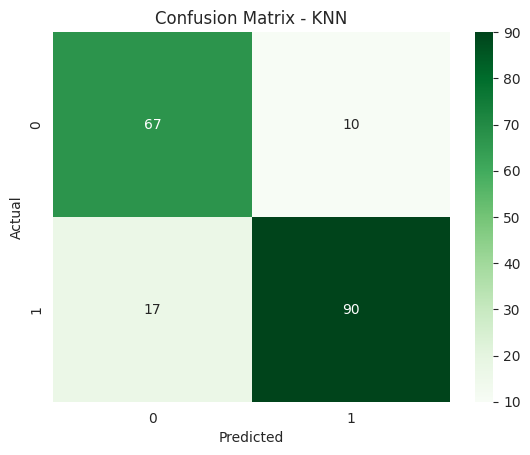

In [161]:
# Cell 14: Metrics for KNN
print("="*50)
print(" KNN - PERFORMANCE REPORT")
print("="*50)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_proba_knn)

print(f" Test Accuracy: {accuracy_knn:.4f}")
print(f" ROC-AUC Score: {roc_auc_knn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

 MODEL COMPARISON 
              Model  Cross-Validated Accuracy  Test Accuracy  ROC-AUC
Logistic Regression                  0.863759       0.853261 0.926690
                KNN                  0.855568       0.853261 0.923656


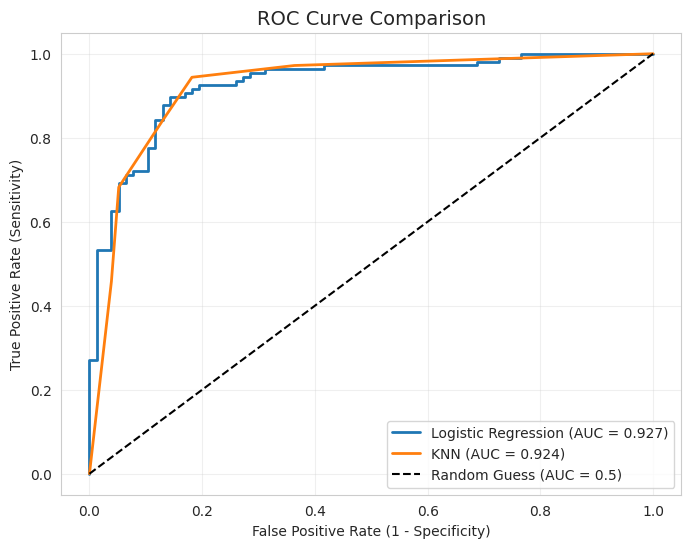


 Best performing model on test data: Logistic Regression


In [162]:
# Cell 15: Side-by-side comparison + ROC Curves
print("="*60)
print(" MODEL COMPARISON ")
print("="*60)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN'],
    'Cross-Validated Accuracy': [cv_scores_lr.mean(), cv_scores_knn.mean()],
    'Test Accuracy': [accuracy_lr, accuracy_knn],
    'ROC-AUC': [roc_auc_lr, roc_auc_knn]
})
print(comparison.to_string(index=False))

# --- Plot ROC Curves ---
plt.figure(figsize=(8, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})', linewidth=2)

# KNN ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.3f})', linewidth=2)

# Diagonal line (Random Guess)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison', size=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Determine the best model
if accuracy_lr >= accuracy_knn:
    best_model = "Logistic Regression"
else:
    best_model = "KNN"
print(f"\n Best performing model on test data: {best_model}")

In [177]:
# Cell 16: Interactive Prediction with Risk Drivers
age = 38  # @param {type:"slider", min:20, max:100, step:1}
sex = "M"  # @param ["M", "F"]
chest_pain = "NAP"  # @param ["ATA", "NAP", "ASY", "TA"]
resting_bp = 138  # @param {type:"integer"}
cholesterol = 175  # @param {type:"integer"}
fasting_bs = 0  # @param [0, 1]
resting_ecg = "Normal"  # @param ["Normal", "ST", "LVH"]
max_hr = 173  # @param {type:"slider", min:60, max:220, step:1}
exercise_angina = "N"  # @param ["N", "Y"]
oldpeak = 1.2  # @param {type:"number"}
st_slope = "Up"  # @param ["Up", "Flat", "Down"]

input_data = pd.DataFrame({
    'Age': [age], 'Sex': [sex], 'ChestPainType': [chest_pain],
    'RestingBP': [resting_bp], 'Cholesterol': [cholesterol],
    'FastingBS': [fasting_bs], 'RestingECG': [resting_ecg],
    'MaxHR': [max_hr], 'ExerciseAngina': [exercise_angina],
    'Oldpeak': [oldpeak], 'ST_Slope': [st_slope]
})

input_encoded = pd.get_dummies(input_data)
input_encoded = input_encoded.reindex(columns=X_encoded.columns, fill_value=0)
input_scaled = scaler.transform(input_encoded)

prediction = lr.predict(input_scaled)[0]
probability = lr.predict_proba(input_scaled)[0][1]

print("\n" + "="*50)
print("HEART DISEASE RISK ASSESSMENT")
print("="*50)

if prediction == 1:
    print(f"STATUS: HIGH RISK")
    print(f"Probability: {probability*100:.2f}%")

    contributions = lr.coef_[0] * input_scaled[0]
    contrib_df = pd.DataFrame({'Feature': X_encoded.columns, 'Contribution': contributions})
    contrib_df = contrib_df[contrib_df['Contribution'] > 0].sort_values('Contribution', ascending=False)

    print("\nTop factors influencing this HIGH RISK prediction:")
    for idx, row in contrib_df.head(5).iterrows():
        print(f"  - {row['Feature']}: +{row['Contribution']:.3f}")
else:
    print(f"STATUS: LOW RISK")
    print(f"Probability: {probability*100:.2f}%")
    contributions = lr.coef_[0] * input_scaled[0]
    contrib_df = pd.DataFrame({'Feature': X_encoded.columns, 'Contribution': contributions})
    contrib_df = contrib_df[contrib_df['Contribution'] < 0].sort_values('Contribution', ascending=True)
    print("\nFeatures reducing risk:")
    for idx, row in contrib_df.head(5).iterrows():
        print(f"  - {row['Feature']}: {row['Contribution']:.3f}")
print("="*50)
print("Disclaimer: Educational model only.")


HEART DISEASE RISK ASSESSMENT
STATUS: LOW RISK
Probability: 8.30%

Features reducing risk:
  - ChestPainType_NAP: -1.175
  - ST_Slope_Flat: -0.678
  - ST_Slope_Up: -0.644
  - ExerciseAngina_Y: -0.450
  - Age: -0.232
Disclaimer: Educational model only.
